In [3]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "../pipeline/data/annotations"

In [4]:
def load_annotations(data_dir):
    data = []
    
    for f in os.listdir(data_dir):
        if f.endswith(".json"):
            path = os.path.join(data_dir, f)
            with open(path, "r") as fp:
                try:
                    js = json.load(fp)
                    js["_file"] = f
                    data.append(js)
                except Exception as e:
                    print("Failed:", f, e)
                    
    return data

annotations = load_annotations(DATA_DIR)
print("Loaded:", len(annotations))

Loaded: 22


In [5]:
annotations[0].keys()

dict_keys(['video_id', 'exercise', 'CAMERA_POSITION', 'expert', 'video', 'fps', 'n_frames', 'confidence', 'trajectory', 'legs_trajectory', 'arm_Trajectory', 'core_', 'error_rate', 'LANGUAGE', '_file'])

In [6]:
for k, v in annotations[0].items():
    print(k, type(v))

video_id <class 'str'>
exercise <class 'str'>
CAMERA_POSITION <class 'str'>
expert <class 'bool'>
video <class 'str'>
fps <class 'float'>
n_frames <class 'int'>
confidence <class 'list'>
trajectory <class 'list'>
legs_trajectory <class 'list'>
arm_Trajectory <class 'list'>
core_ <class 'list'>
error_rate <class 'list'>
LANGUAGE <class 'str'>
_file <class 'str'>


In [7]:
def plot_signal(seg, key):
    signal = seg.get(key)
    
    if not isinstance(signal, list):
        print("Not a signal:", key)
        return
    
    import numpy as np
    import matplotlib.pyplot as plt
    
    signal = np.array(signal)
    
    plt.figure(figsize=(12,4))
    plt.plot(signal)
    plt.title(f"{key} | {seg.get('_file')}")
    plt.grid(True)
    plt.show()

In [18]:
video_file = os.path.join("../pipeline/data/unknown/RAW/train/annotations/", "utzhPQuXWcA_seg01.mp4.json")

with open(video_file, "r") as f:
    video_data = json.load(f)

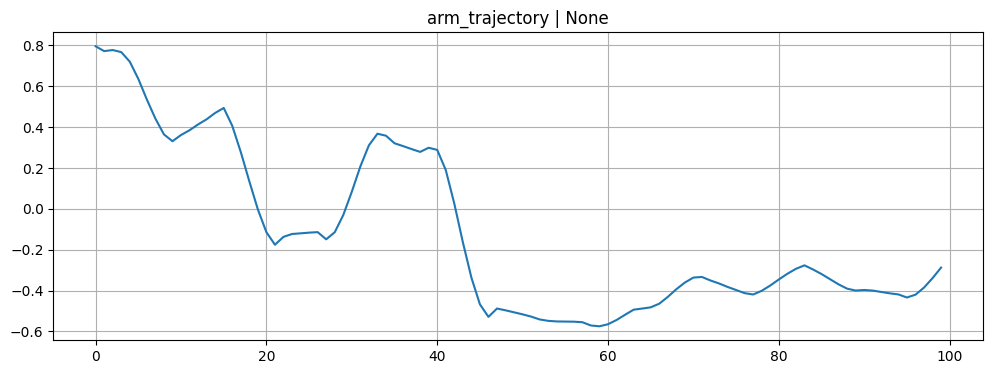

In [19]:
plot_signal(video_data, "arm_trajectory")

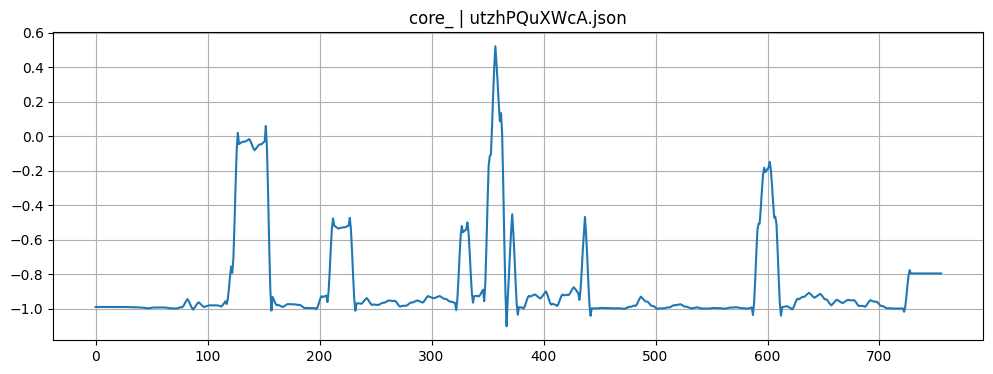

In [22]:
plot_signal(annotations[6], "core_")